In [1]:
%matplotlib inline
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Wong-Wang Decision Model

The **(reduced) Wong-Wang model** is a two-variable attractor network for two-alternative perceptual decision making. The state variables $S_1, S_2$ are the NMDA gating fractions of two competing, mutually inhibiting selective populations. Stimulus *coherence* biases the inputs toward one population; recurrent excitation and cross-inhibition then drive a winner-take-all transition to one of two stable attractors (the 'decision').

**Reference:** Wong & Wang (2006), *A recurrent network mechanism of time integration in perceptual decisions*, Journal of Neuroscience 26(4):1314-1328.

## Build the model

In [2]:
node = brainmass.WongWangStep(in_size=1)
node

WongWangStep(
  in_size=(1,),
  out_size=(1,),
  tau_S=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Quantity(0.1, "s")
  ),
  gamma=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.641, dtype=float32)
  ),
  a=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Quantity(270., "Hz / nA")
  ),
  theta=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Quantity(0.31, "nA")
  ),
  J_N11=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Quantity(0.2609, "nA")
  ),
  J_N22=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Quantity(0.2609, "nA")
  ),
  J_N12=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Quantity(0.0497, "nA")
  ),
  J_N21=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Quantity(0.0497, "nA")
  ),
  J_A_ext=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Quantity(0.0002243, "nC")
  ),
  mu_0=Const(
    fit=False,
    t=IdentityT(),
    reg=Non

## Run a simulation

A positive `coherence` biases the evidence toward population 1. We watch the two gating variables compete.

In [3]:
sim = brainmass.Simulator(node, dt=0.5 * u.ms)
res = sim.run(2000. * u.ms, inputs=lambda i, t: 25.6,
              monitors=['S1', 'S2'])
res['S1'].shape

(4000, 1)

## Visualize

The winning population's gating variable rises to a high stable value while the loser is suppressed — a categorical decision.

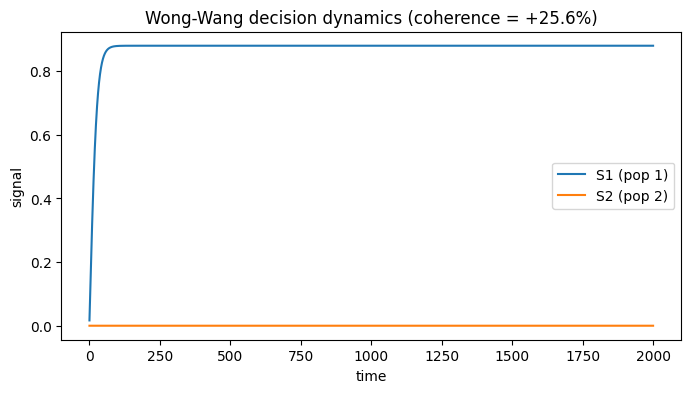

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
brainmass.viz.plot_timeseries(
    jnp.concatenate([res['S1'], res['S2']], axis=1), ts=res['ts'],
    labels=['S1 (pop 1)', 'S2 (pop 2)'], ax=ax)
ax.set_title('Wong-Wang decision dynamics (coherence = +25.6%)')
plt.show()

## Try it: vary the stimulus coherence

Stronger coherence speeds and sharpens the decision; near-zero coherence makes the outcome slow and noise-sensitive.

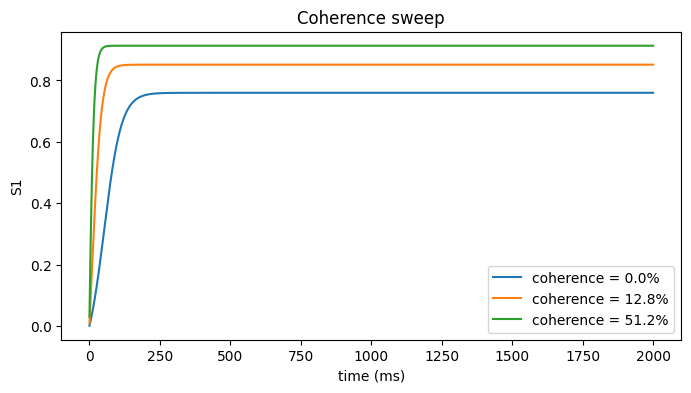

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for coh in [0.0, 12.8, 51.2]:
    m = brainmass.WongWangStep(in_size=1)
    r = brainmass.Simulator(m, dt=0.5 * u.ms).run(
        2000. * u.ms, inputs=lambda i, t, c=coh: c, monitors=['S1'])
    ax.plot(u.get_magnitude(r['ts']), u.get_magnitude(r['S1'])[:, 0],
            label=f'coherence = {coh}%')
ax.set_xlabel('time (ms)'); ax.set_ylabel('S1'); ax.legend()
ax.set_title('Coherence sweep')
plt.show()